In [1]:
import sys
sys.path.append("../")

import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from env import Market
from data_loader import PairData
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

YEAR = 252

pairs = [
    ("MPC",  "PSX"),
    ("PEP",  "KO"),
    ("AAPL", "MSFT"),
    ("JPM",  "BAC"),
    ("XOM",  "CVX"),
    ("MCD",  "YUM"),
    ("GS",   "MS"),
    ("V",    "MA"),
    ("HD",   "LOW"),
    ("T",    "VZ"),
]

def run_walkforward(pair_data):
    n = len(pair_data)
    combined = {"pnl": [], "s0": [], "s1": [], "spreads": [], "zscores": [],
                "entries": [], "exits": [], "labels": pair_data.labels}
    capital = 10000.0
    offset = 0

    year_start = 0
    while year_start + YEAR < n:
        train_end = year_start + YEAR
        test_end  = min(train_end + YEAR, n)

        jres = coint_johansen(np.log(pair_data.s[:, year_start:train_end]).T, det_order=0, k_ar_diff=1)
        cv   = jres.evec[:, 0]
        beta = -cv[1] / cv[0]

        if test_end - train_end <= 60:  # skip partial years shorter than past_window
            break

        test_data = pair_data.slice(train_end, test_end)
        # intercept = mean of training spread, so test spread is centred around 0
        log_s0_train = np.log(pair_data.s[0, year_start:train_end])
        log_s1_train = np.log(pair_data.s[1, year_start:train_end])
        intercept = float((log_s0_train - beta * log_s1_train).mean())
        env_year  = Market(test_data, fixed_beta=beta, spread_intercept=intercept, initial_capital=capital)
        r = run_strategy(env_year, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))

        combined["pnl"].append(r["pnl"])
        combined["s0"].append(r["s0"])
        combined["s1"].append(r["s1"])
        combined["spreads"].append(r["spreads"])
        combined["zscores"].append(r["zscores"])
        combined["entries"] += [e + offset for e in r["entries"]]
        combined["exits"]   += [e + offset for e in r["exits"]]
        offset  += len(r["pnl"])
        capital  = float(r["pnl"][~np.isnan(r["pnl"])][-1])
        print(f"  year {year_start//YEAR+1:>2}  β={beta:.3f}  end=${capital:.0f}")

        year_start += YEAR

    combined["pnl"]     = np.concatenate(combined["pnl"])
    combined["s0"]      = np.concatenate(combined["s0"])
    combined["s1"]      = np.concatenate(combined["s1"])
    combined["spreads"] = np.concatenate(combined["spreads"])
    combined["zscores"] = np.concatenate(combined["zscores"])
    return combined


=== MPC/PSX ===
  year  1  β=1.120  end=$9726
  year  2  β=0.789  end=$10390
  year  3  β=-1.617  end=$9914
  year  4  β=-5.661  end=$11361
  year  5  β=10.175  end=$12060
  year  6  β=1.588  end=$12350
  year  7  β=1.080  end=$12121
  year  8  β=1.629  end=$13567
  year  9  β=0.963  end=$17172
  year 10  β=4.225  end=$16218
  year 11  β=2.031  end=$15595
  year 12  β=1.087  end=$14931
  year 13  β=0.542  end=$15046


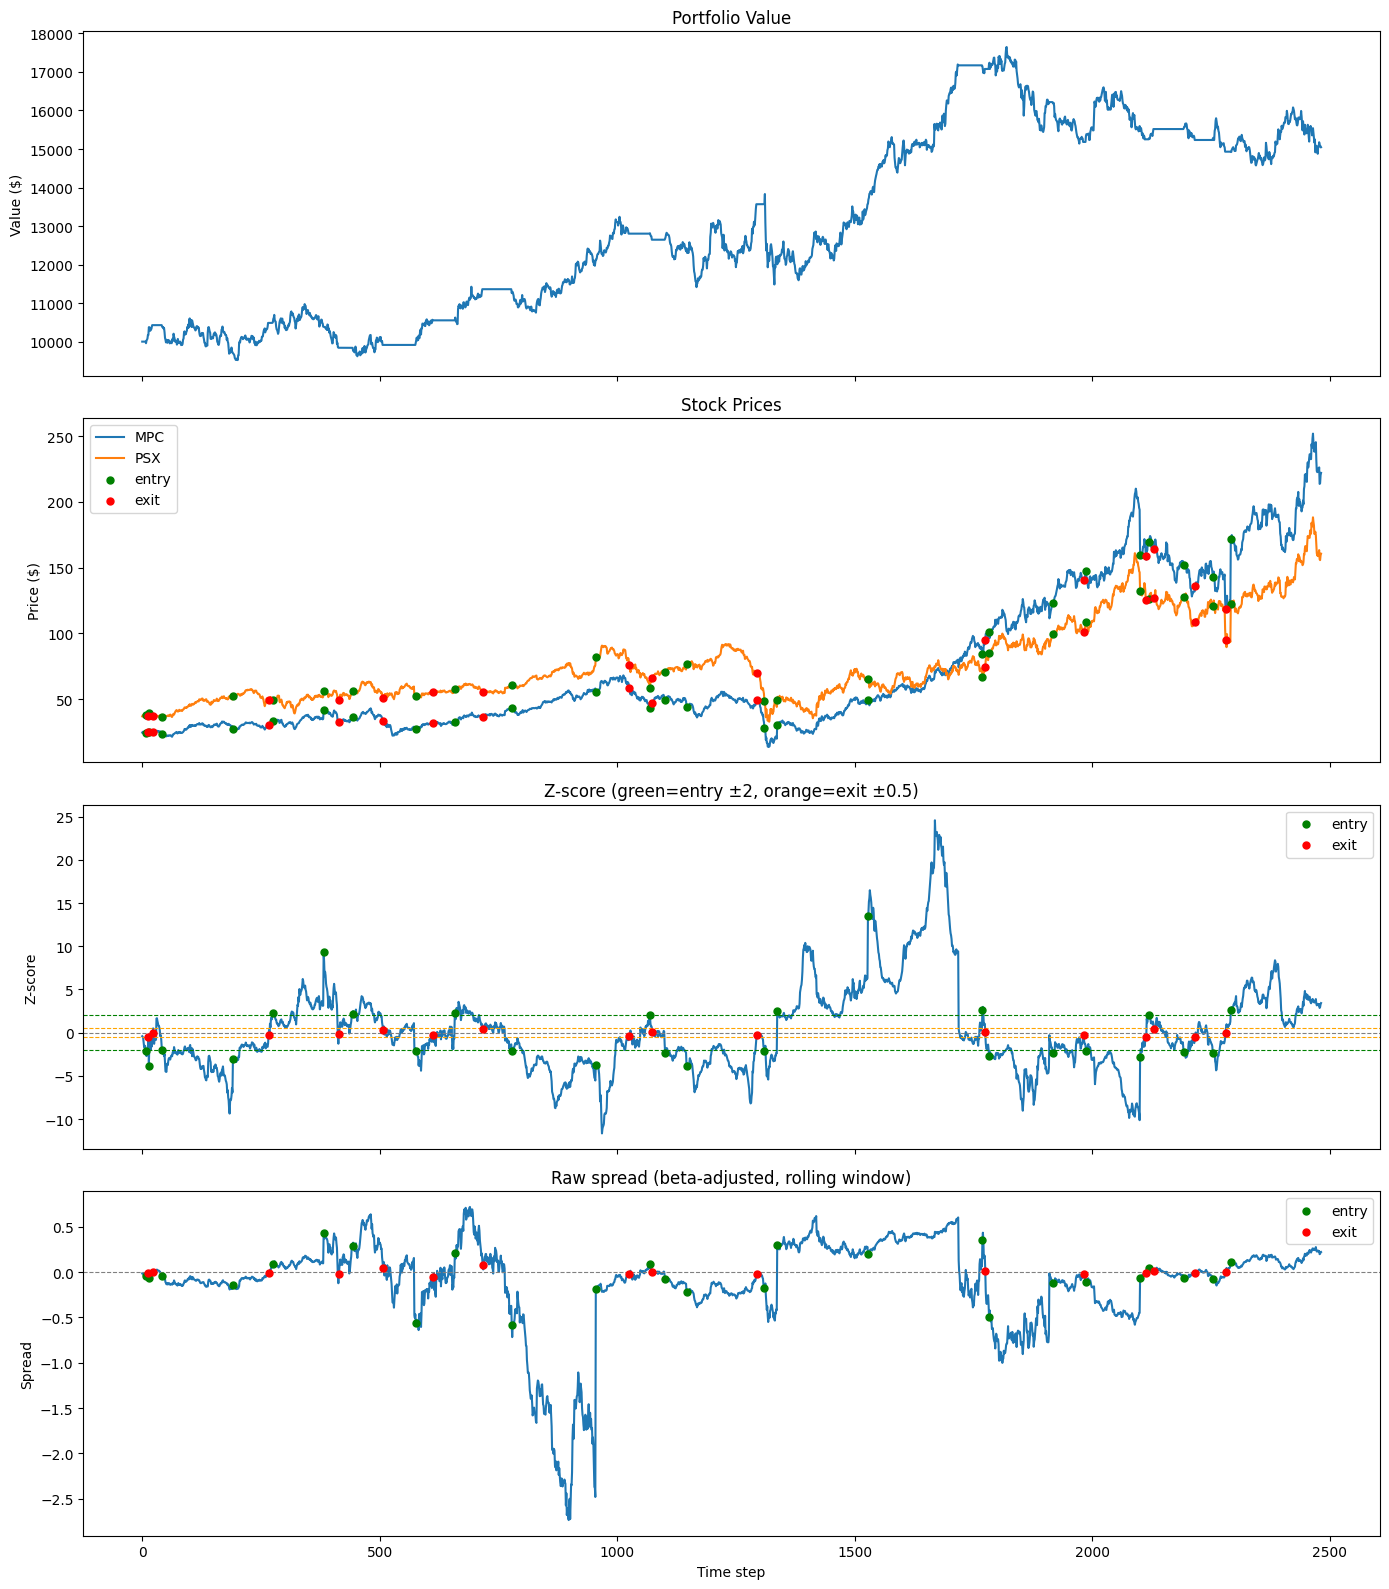


=== PEP/KO ===
  year  1  β=0.458  end=$10231
  year  2  β=0.738  end=$10791
  year  3  β=1.496  end=$10381
  year  4  β=19.560  end=$10916
  year  5  β=0.317  end=$10286
  year  6  β=0.214  end=$9904
  year  7  β=1.487  end=$10047
  year  8  β=1.073  end=$10301
  year  9  β=3.963  end=$10627
  year 10  β=0.635  end=$10330
  year 11  β=2.010  end=$10841
  year 12  β=2.992  end=$10417
  year 13  β=3.221  end=$10285
  year 14  β=0.124  end=$10847
  year 15  β=0.644  end=$11010
  year 16  β=-0.082  end=$10531
  year 17  β=-4.962  end=$10560
  year 18  β=0.861  end=$12099
  year 19  β=-1.518  end=$12525


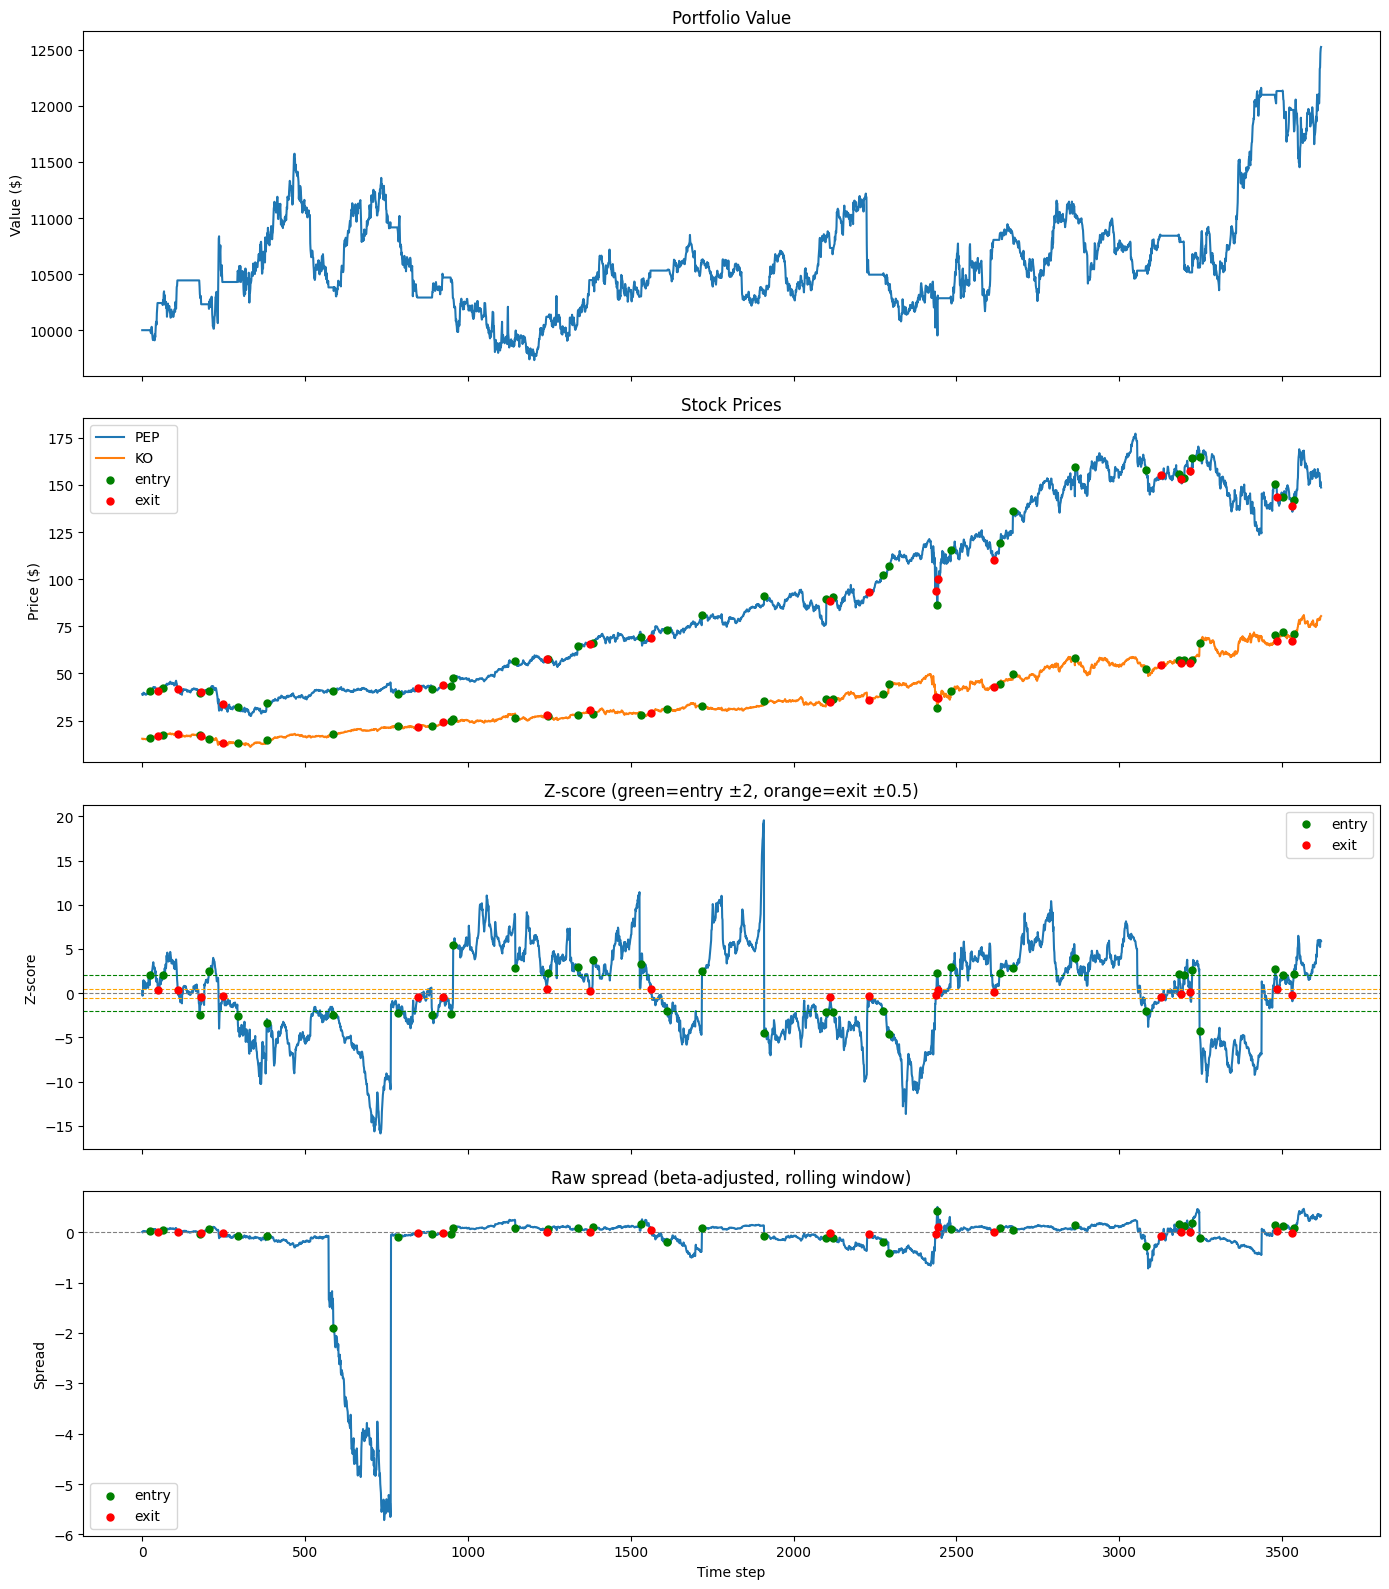


=== AAPL/MSFT ===
  year  1  β=1.875  end=$12029
  year  2  β=2.552  end=$11622
  year  3  β=2.111  end=$11946
  year  4  β=2.831  end=$13755
  year  5  β=3.103  end=$15268
  year  6  β=1.968  end=$12654
  year  7  β=0.230  end=$13239
  year  8  β=1.368  end=$14376
  year  9  β=31.099  end=$12561
  year 10  β=-1.007  end=$13389
  year 11  β=1.796  end=$12345
  year 12  β=0.584  end=$12747
  year 13  β=-1.086  end=$13910
  year 14  β=1.301  end=$13442
  year 15  β=0.096  end=$13762
  year 16  β=0.162  end=$13842
  year 17  β=0.879  end=$12229
  year 18  β=-0.093  end=$11098
  year 19  β=-0.179  end=$13364


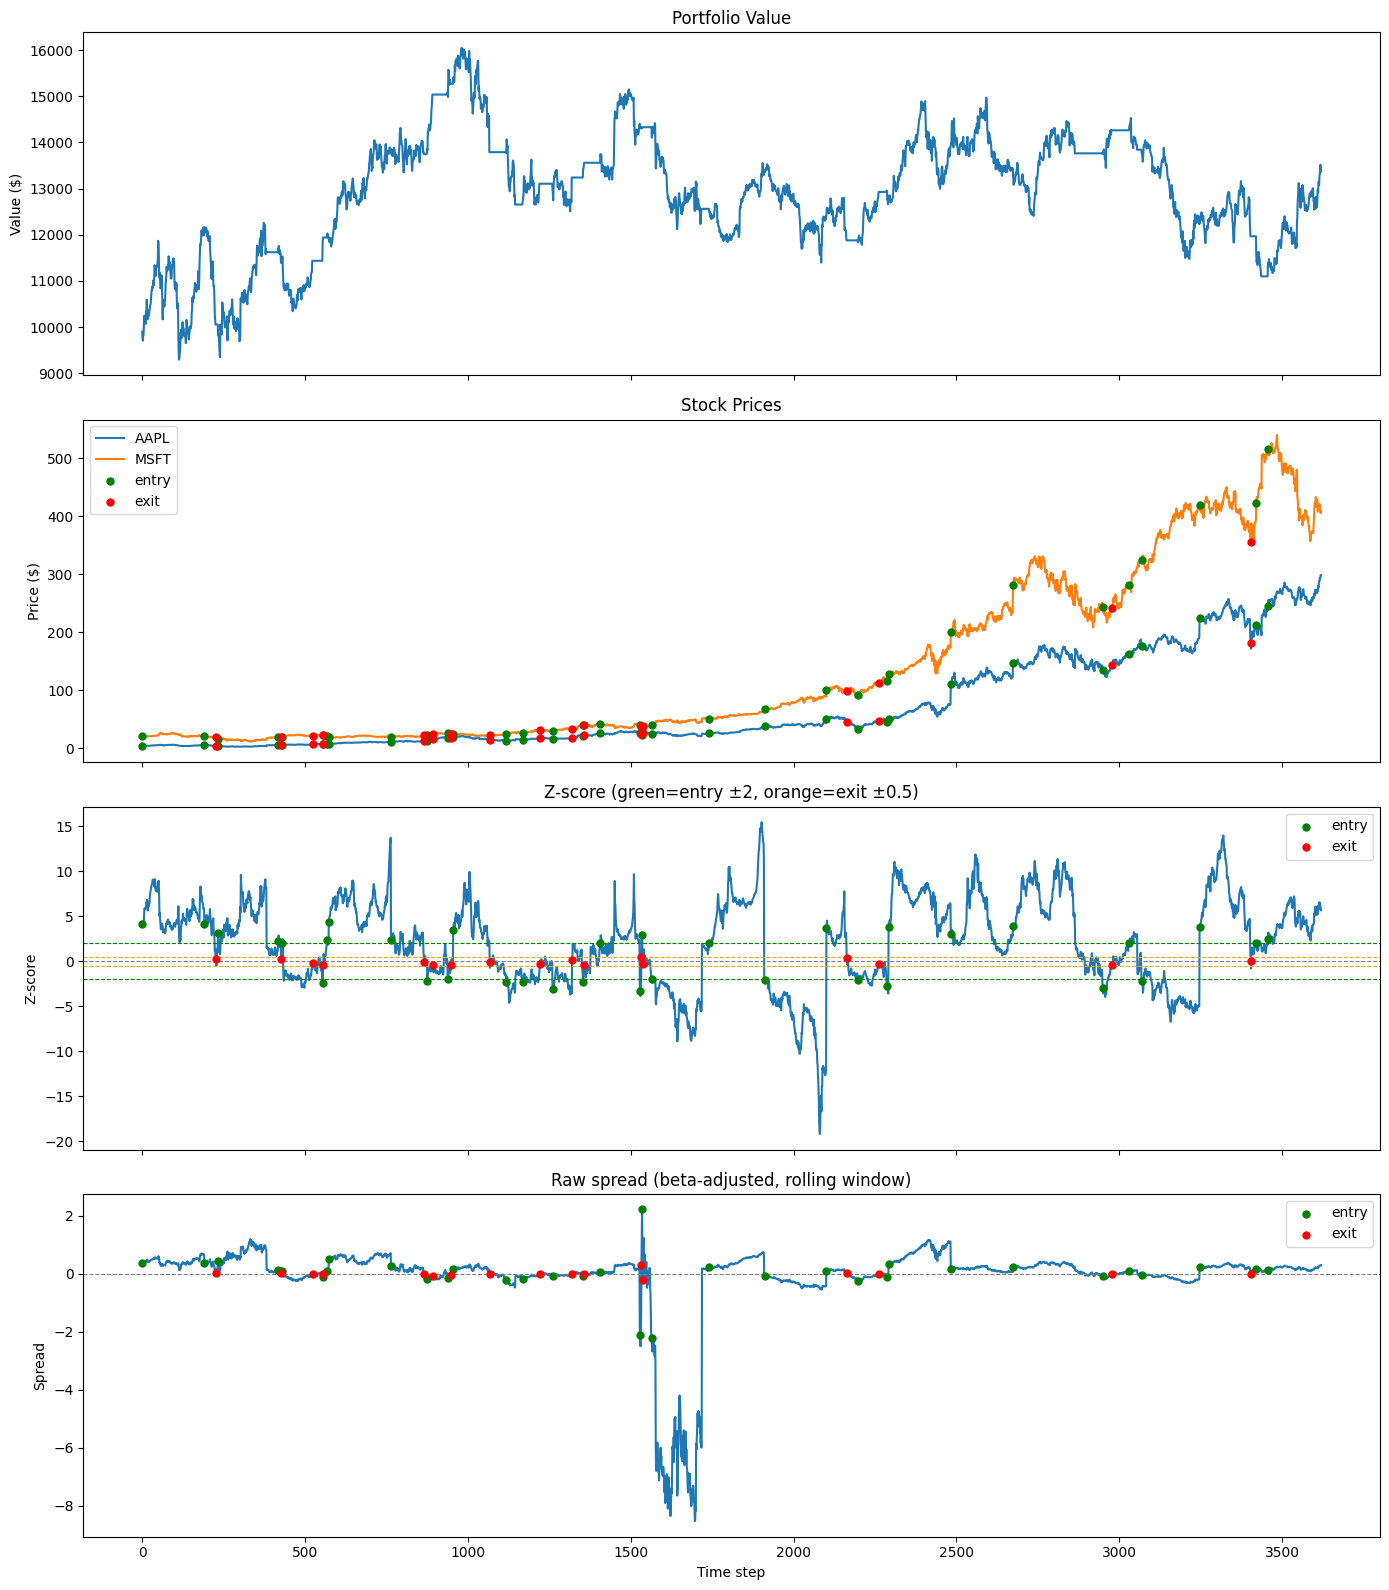


=== JPM/BAC ===
  year  1  β=-4.979  end=$11253
  year  2  β=-0.223  end=$8997
  year  3  β=0.269  end=$9361
  year  4  β=0.818  end=$8481
  year  5  β=-2.675  end=$8486
  year  6  β=0.672  end=$8623
  year  7  β=0.728  end=$7858
  year  8  β=0.459  end=$7486
  year  9  β=-6.774  end=$6957
  year 10  β=0.351  end=$7757
  year 11  β=0.647  end=$8010
  year 12  β=0.857  end=$7918
  year 13  β=-0.370  end=$7950
  year 14  β=0.934  end=$8530
  year 15  β=0.953  end=$8869
  year 16  β=0.849  end=$7729
  year 17  β=-0.835  end=$7842
  year 18  β=1.033  end=$7476
  year 19  β=3.235  end=$7485


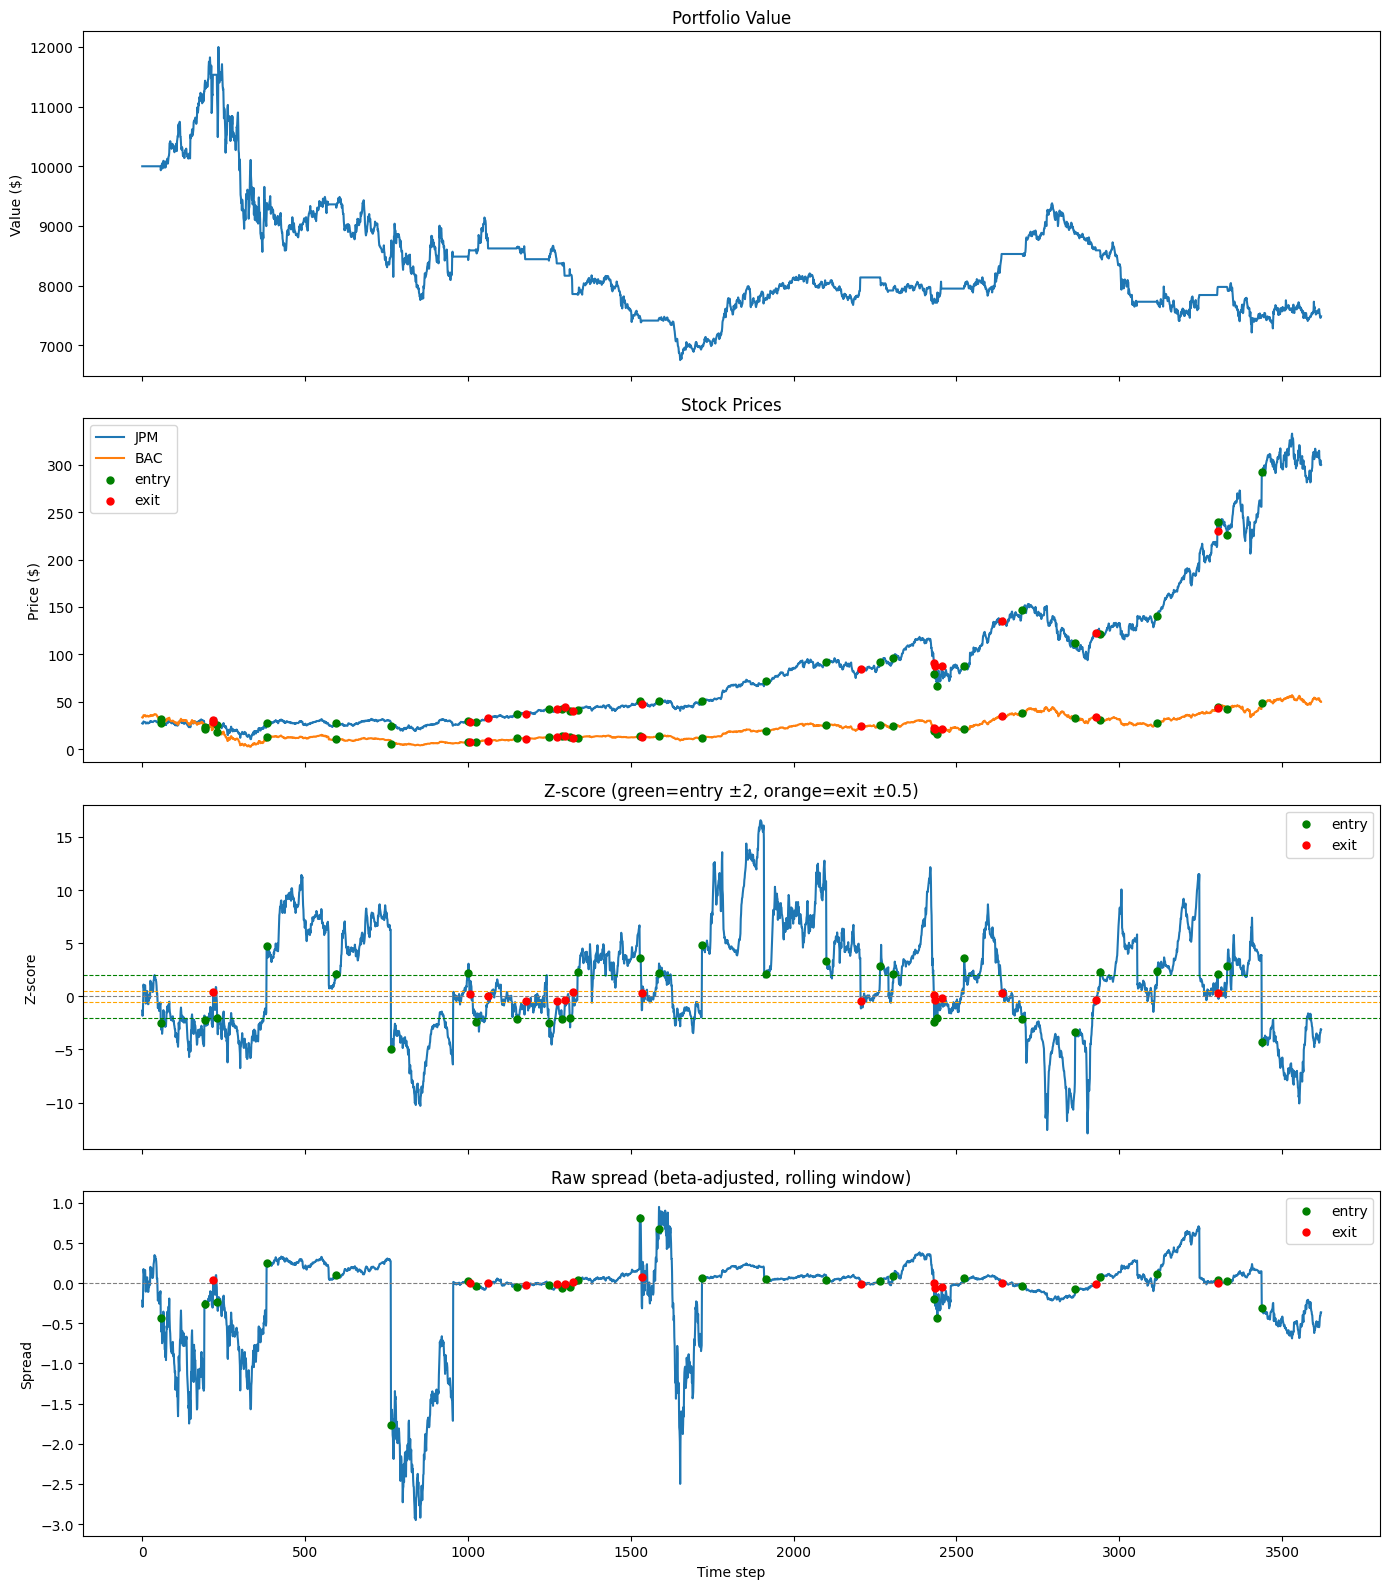


=== XOM/CVX ===
  year  1  β=0.972  end=$10009
  year  2  β=0.603  end=$10744
  year  3  β=0.418  end=$10292
  year  4  β=-0.340  end=$9722
  year  5  β=1.001  end=$10174
  year  6  β=1.657  end=$10030
  year  7  β=0.406  end=$10280
  year  8  β=5.176  end=$10091
  year  9  β=0.690  end=$9558
  year 10  β=0.684  end=$9307
  year 11  β=-0.354  end=$9194
  year 12  β=0.190  end=$9228
  year 13  β=2.986  end=$8738
  year 14  β=1.400  end=$9661
  year 15  β=1.682  end=$9513
  year 16  β=0.839  end=$10299
  year 17  β=2.407  end=$10744
  year 18  β=2.234  end=$10835
  year 19  β=-0.645  end=$11917


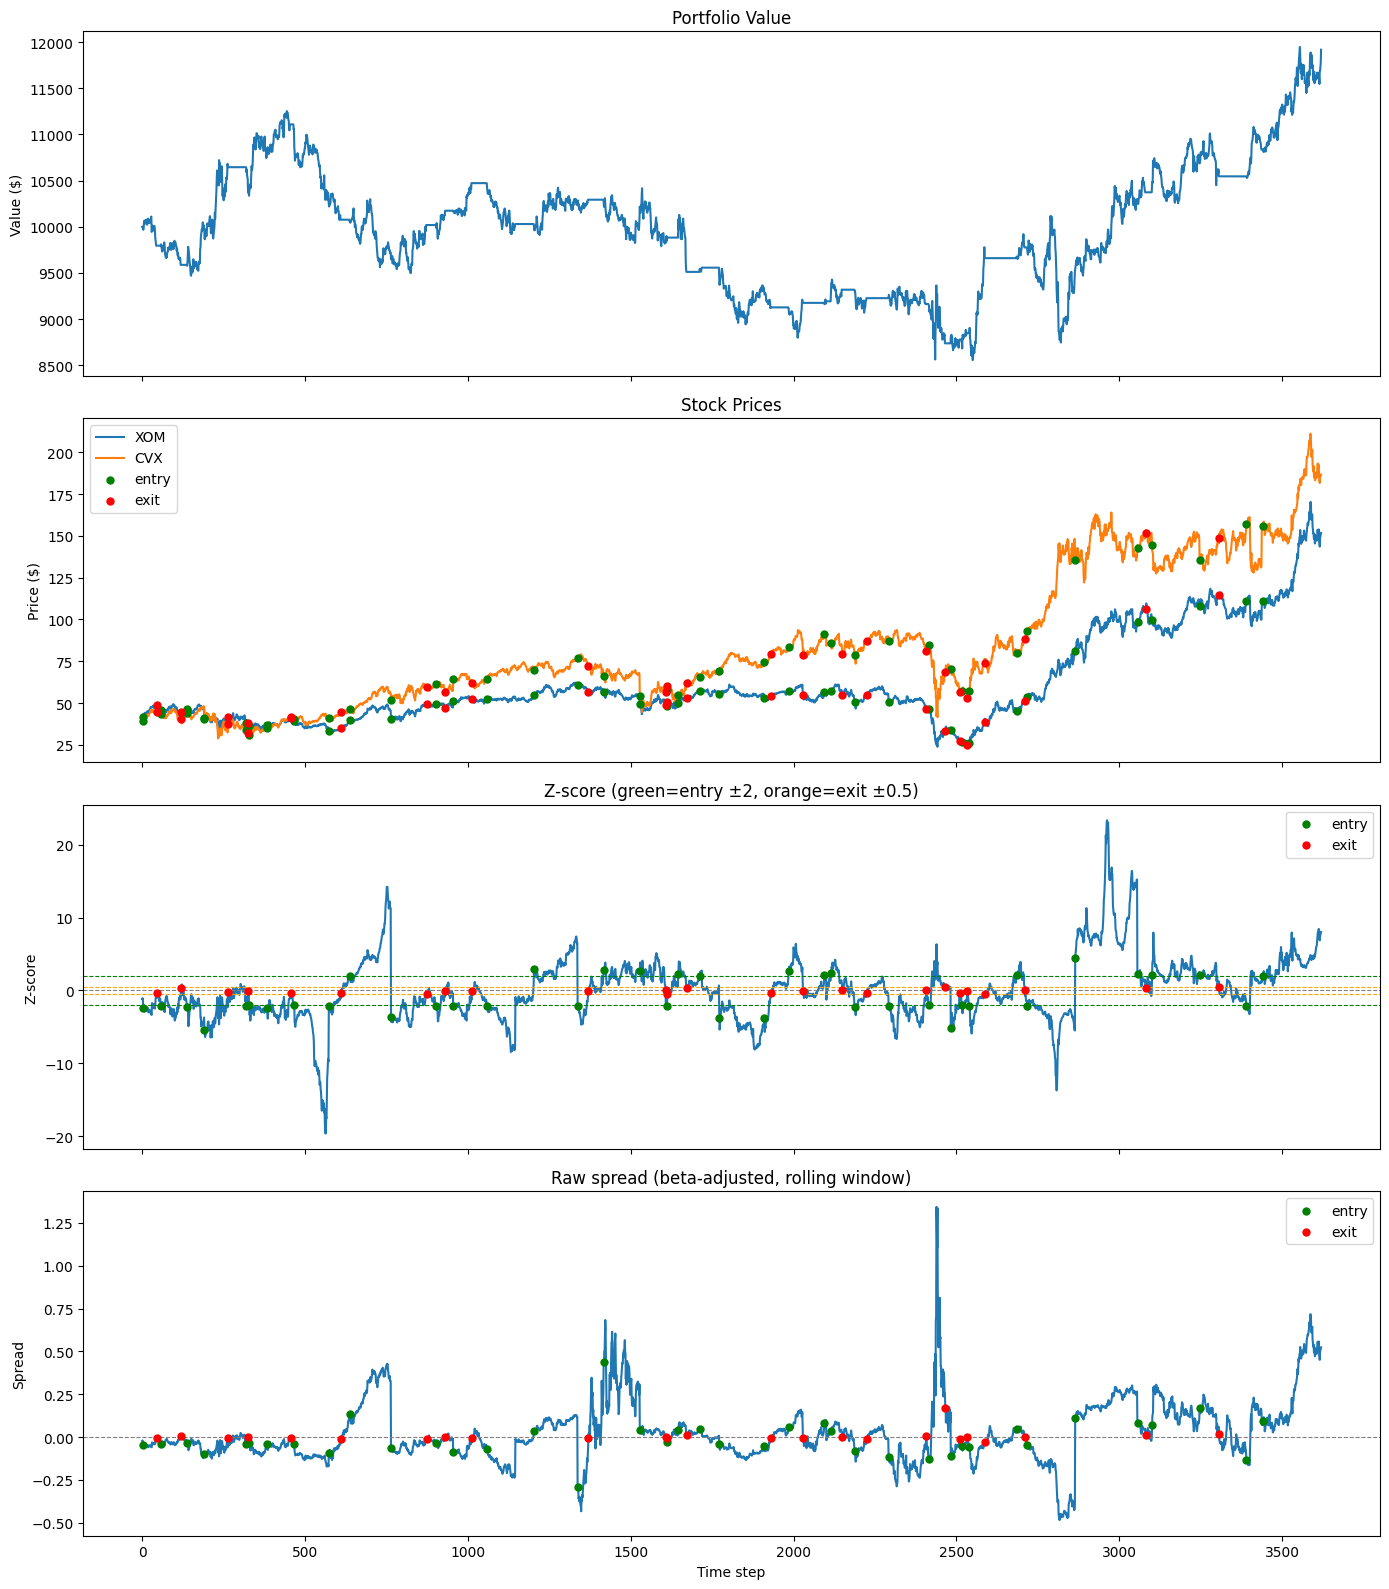


=== MCD/YUM ===
  year  1  β=1.301  end=$10015
  year  2  β=0.985  end=$10353
  year  3  β=0.014  end=$10095
  year  4  β=1.132  end=$10601
  year  5  β=0.548  end=$12195
  year  6  β=-0.162  end=$12652
  year  7  β=10.756  end=$11723
  year  8  β=0.745  end=$12341
  year  9  β=0.343  end=$10848
  year 10  β=-3.286  end=$9850
  year 11  β=2.348  end=$10104
  year 12  β=-0.160  end=$9847
  year 13  β=0.967  end=$9503
  year 14  β=0.505  end=$10296
  year 15  β=0.255  end=$9556
  year 16  β=0.373  end=$9956
  year 17  β=0.758  end=$10419
  year 18  β=-3.507  end=$9971
  year 19  β=1.039  end=$9808


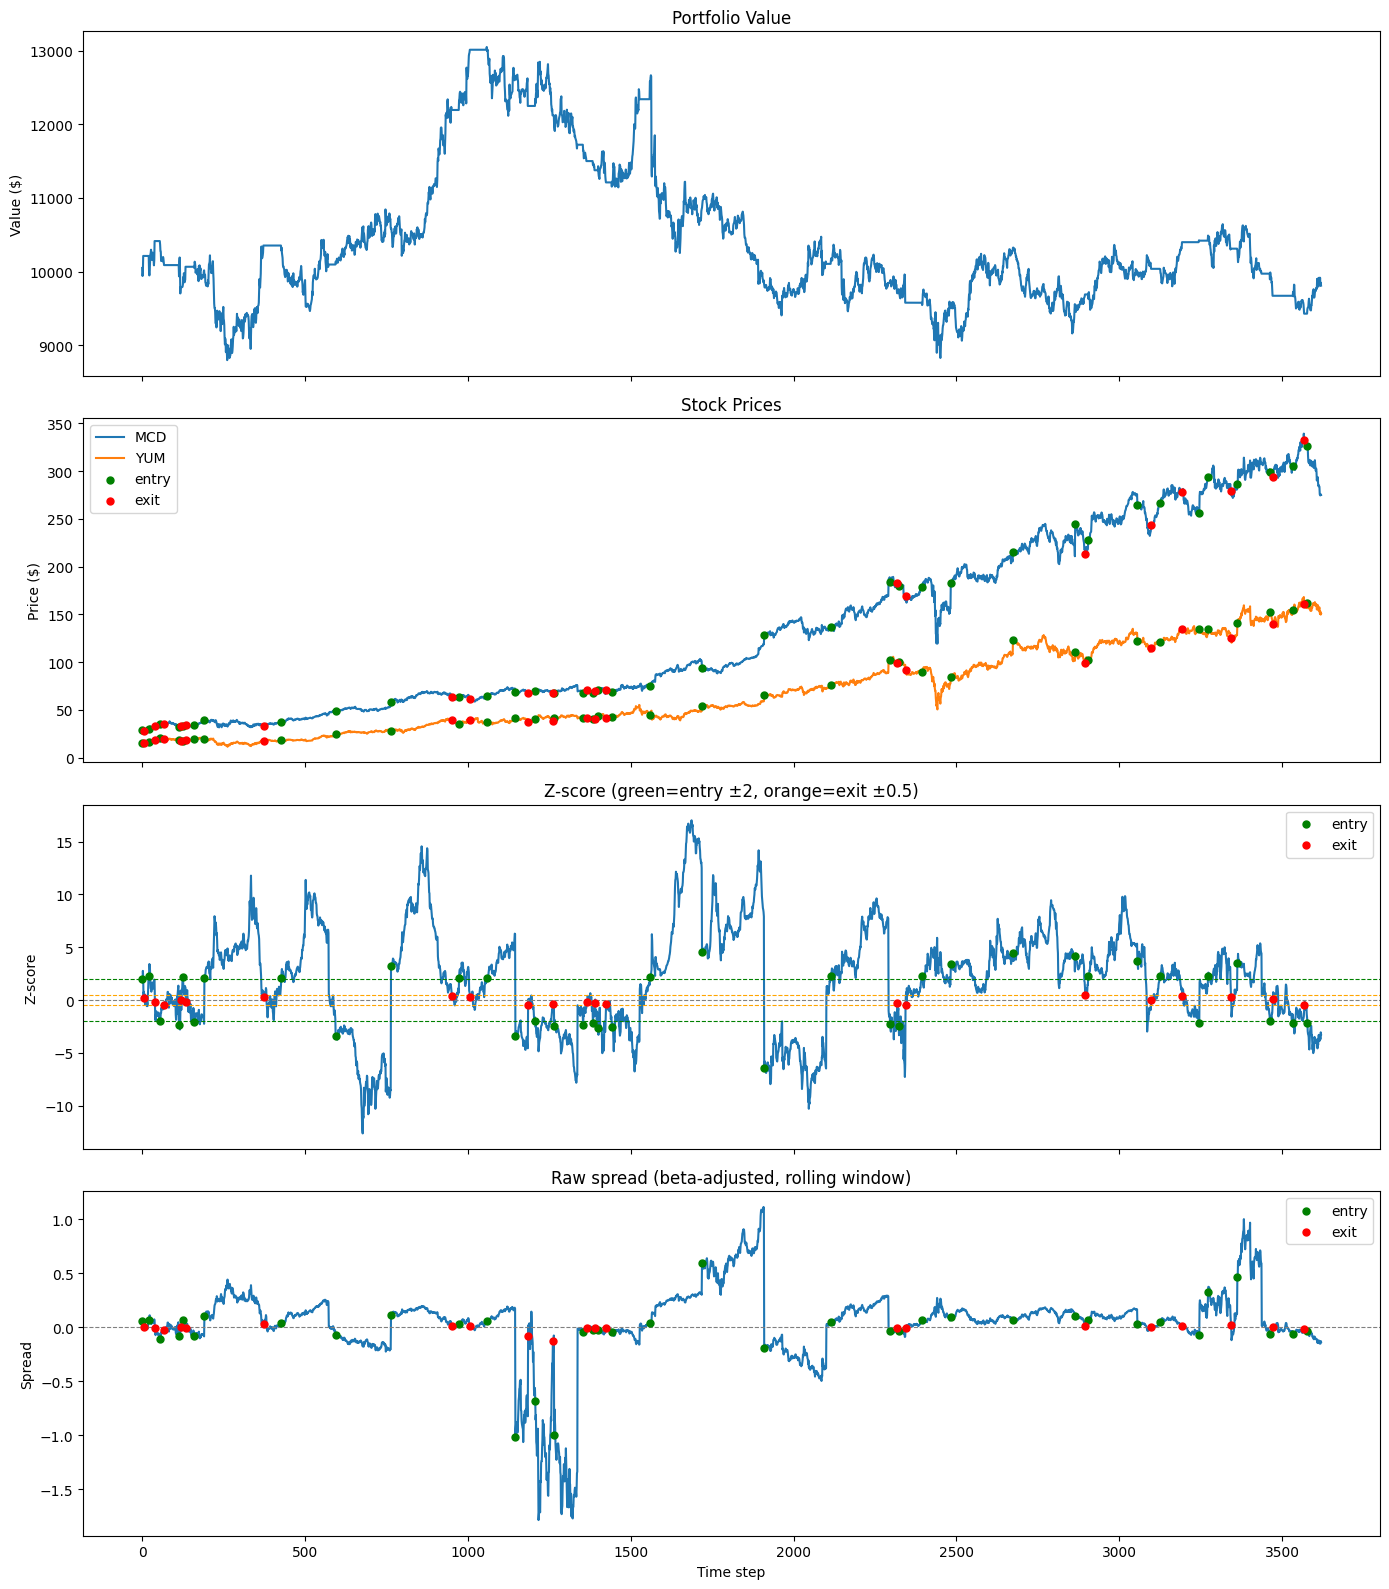


=== GS/MS ===
  year  1  β=1.562  end=$9204
  year  2  β=0.031  end=$8389
  year  3  β=1.034  end=$8925
  year  4  β=2.354  end=$9039
  year  5  β=1.289  end=$8719
  year  6  β=0.860  end=$9517
  year  7  β=0.863  end=$10271
  year  8  β=0.040  end=$10344
  year  9  β=1.120  end=$10050
  year 10  β=0.680  end=$10531
  year 11  β=0.907  end=$11198
  year 12  β=0.604  end=$11268
  year 13  β=1.797  end=$12500
  year 14  β=0.890  end=$11542
  year 15  β=1.121  end=$11667
  year 16  β=1.513  end=$11980
  year 17  β=1.029  end=$10980
  year 18  β=1.804  end=$10811
  year 19  β=0.809  end=$10942


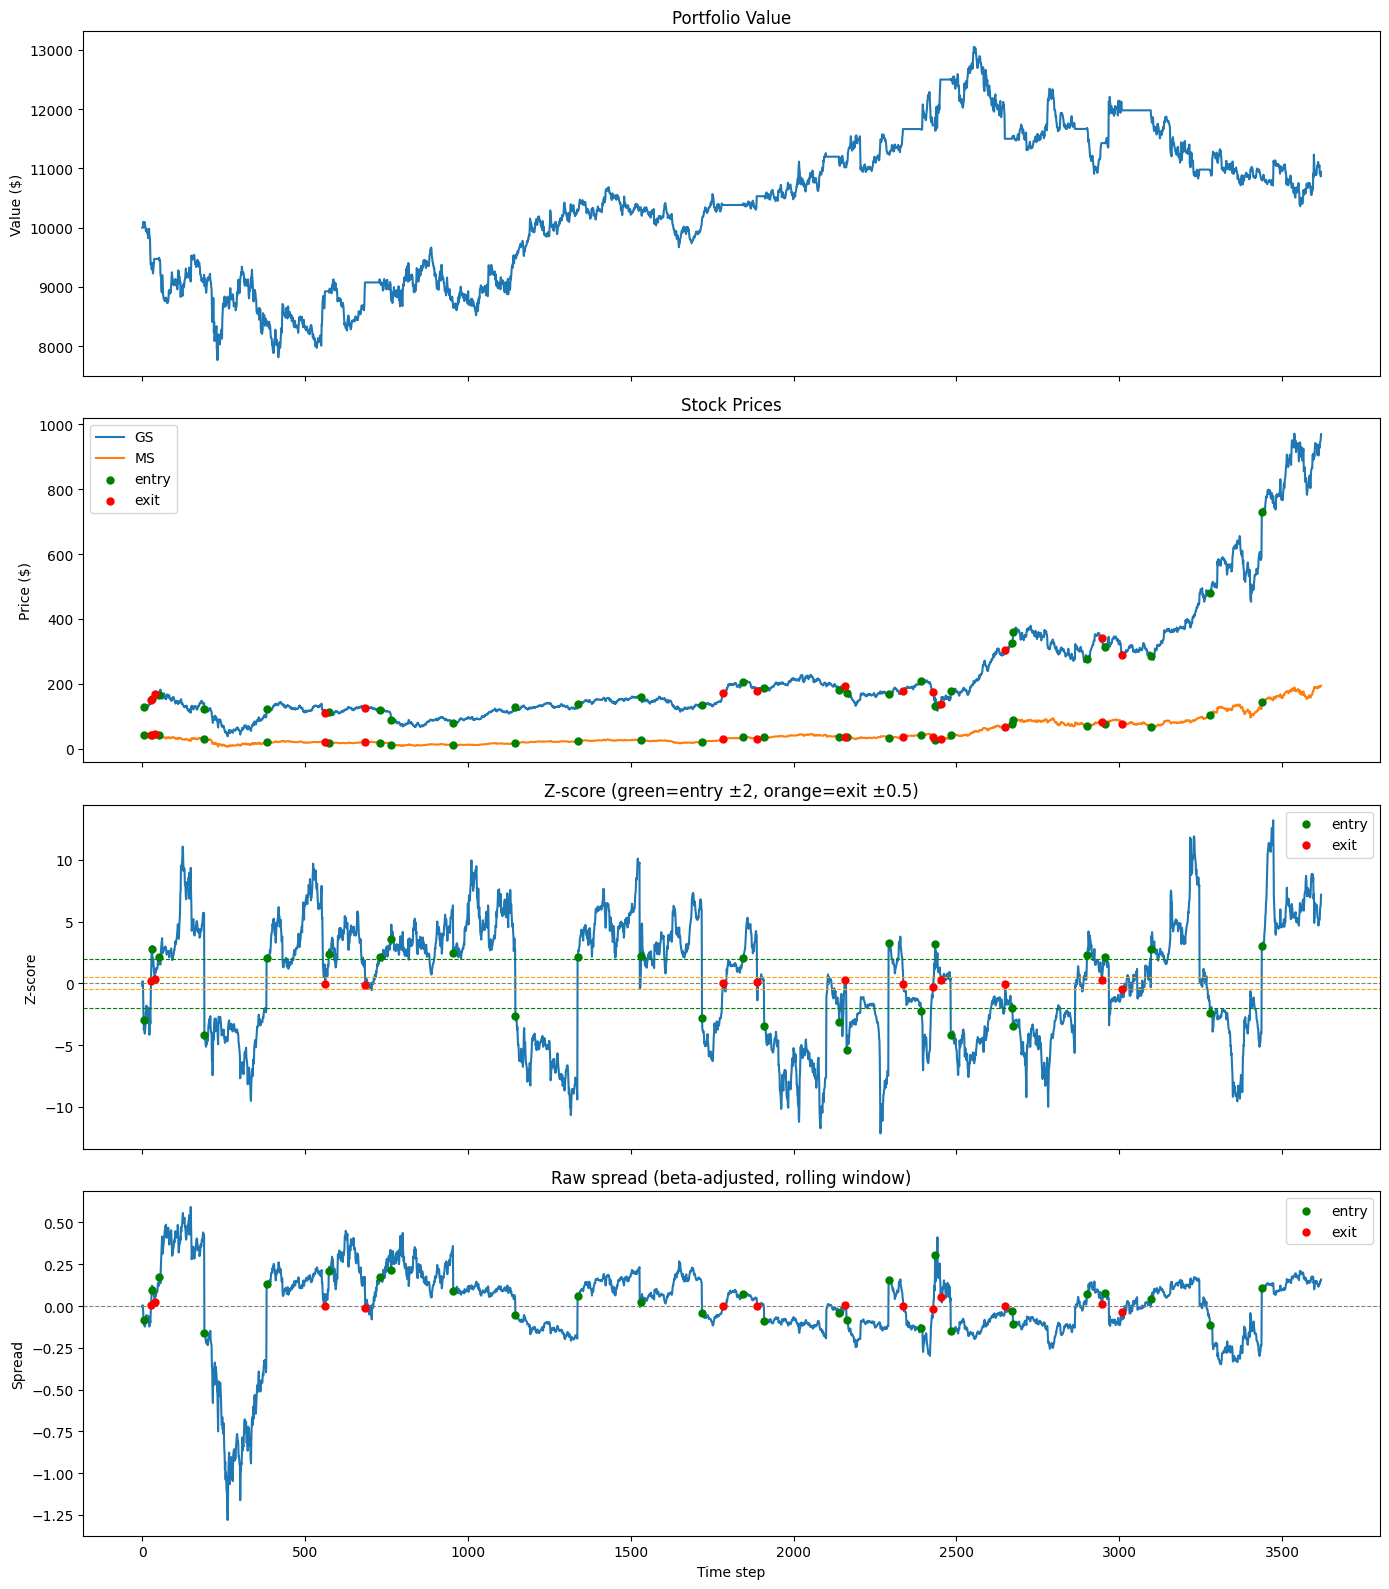


=== V/MA ===
  year  1  β=0.650  end=$9948
  year  2  β=0.843  end=$9106
  year  3  β=-0.272  end=$9094
  year  4  β=1.076  end=$9311
  year  5  β=1.435  end=$8759
  year  6  β=0.613  end=$9028
  year  7  β=1.479  end=$9518
  year  8  β=-5.448  end=$9358
  year  9  β=0.437  end=$8543
  year 10  β=0.689  end=$8312
  year 11  β=0.750  end=$8276
  year 12  β=0.825  end=$8144
  year 13  β=0.574  end=$7992
  year 14  β=5.322  end=$7859
  year 15  β=0.960  end=$7674
  year 16  β=0.951  end=$7797
  year 17  β=1.486  end=$8021


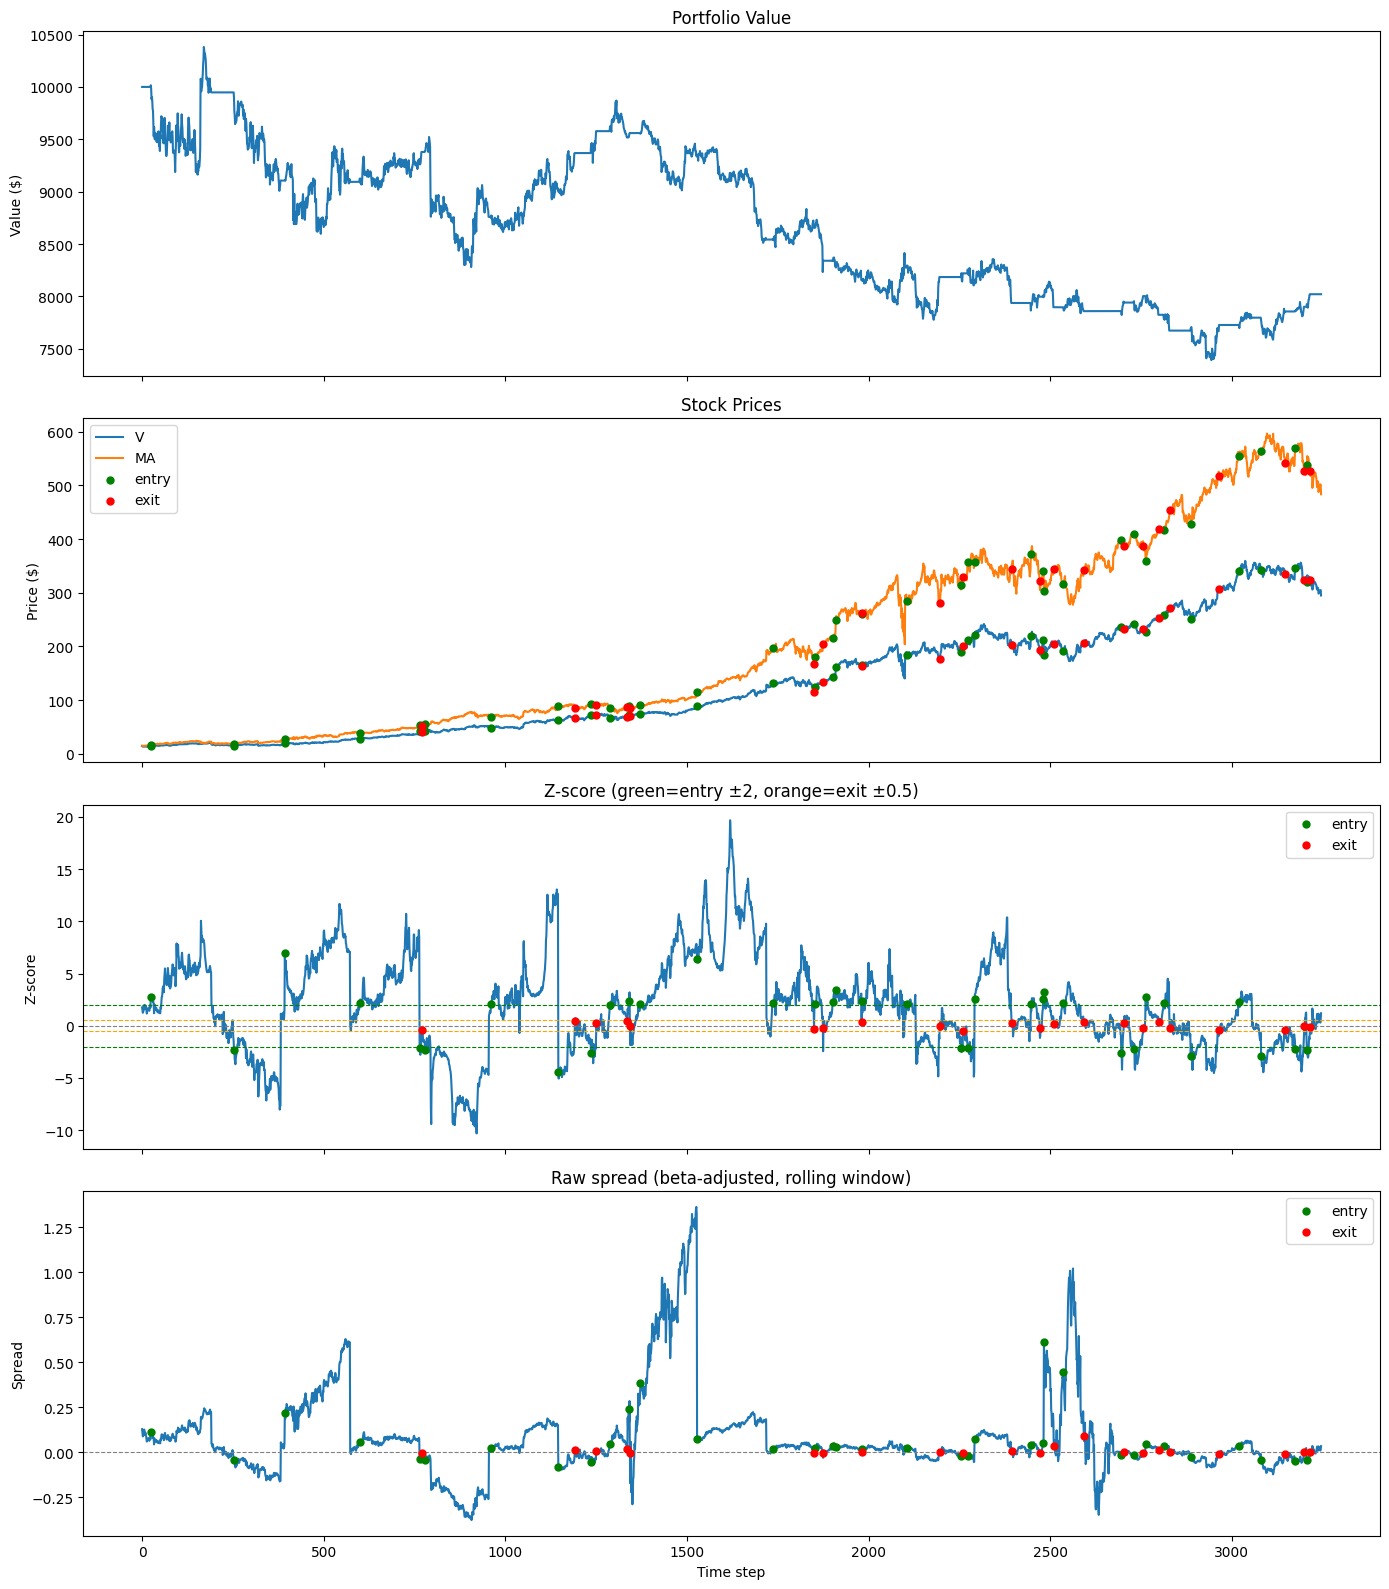


=== HD/LOW ===
  year  1  β=1.142  end=$10533
  year  2  β=1.262  end=$10282
  year  3  β=-0.186  end=$9141
  year  4  β=1.441  end=$9395
  year  5  β=1.204  end=$8885
  year  6  β=1.012  end=$9528
  year  7  β=0.741  end=$9089
  year  8  β=-0.204  end=$9457
  year  9  β=0.725  end=$9389
  year 10  β=1.954  end=$9644
  year 11  β=1.152  end=$9691
  year 12  β=1.092  end=$10432
  year 13  β=0.961  end=$11157
  year 14  β=0.568  end=$11500
  year 15  β=0.922  end=$11752
  year 16  β=0.993  end=$11569
  year 17  β=-152.059  end=$11943
  year 18  β=6.248  end=$11630
  year 19  β=0.544  end=$12170


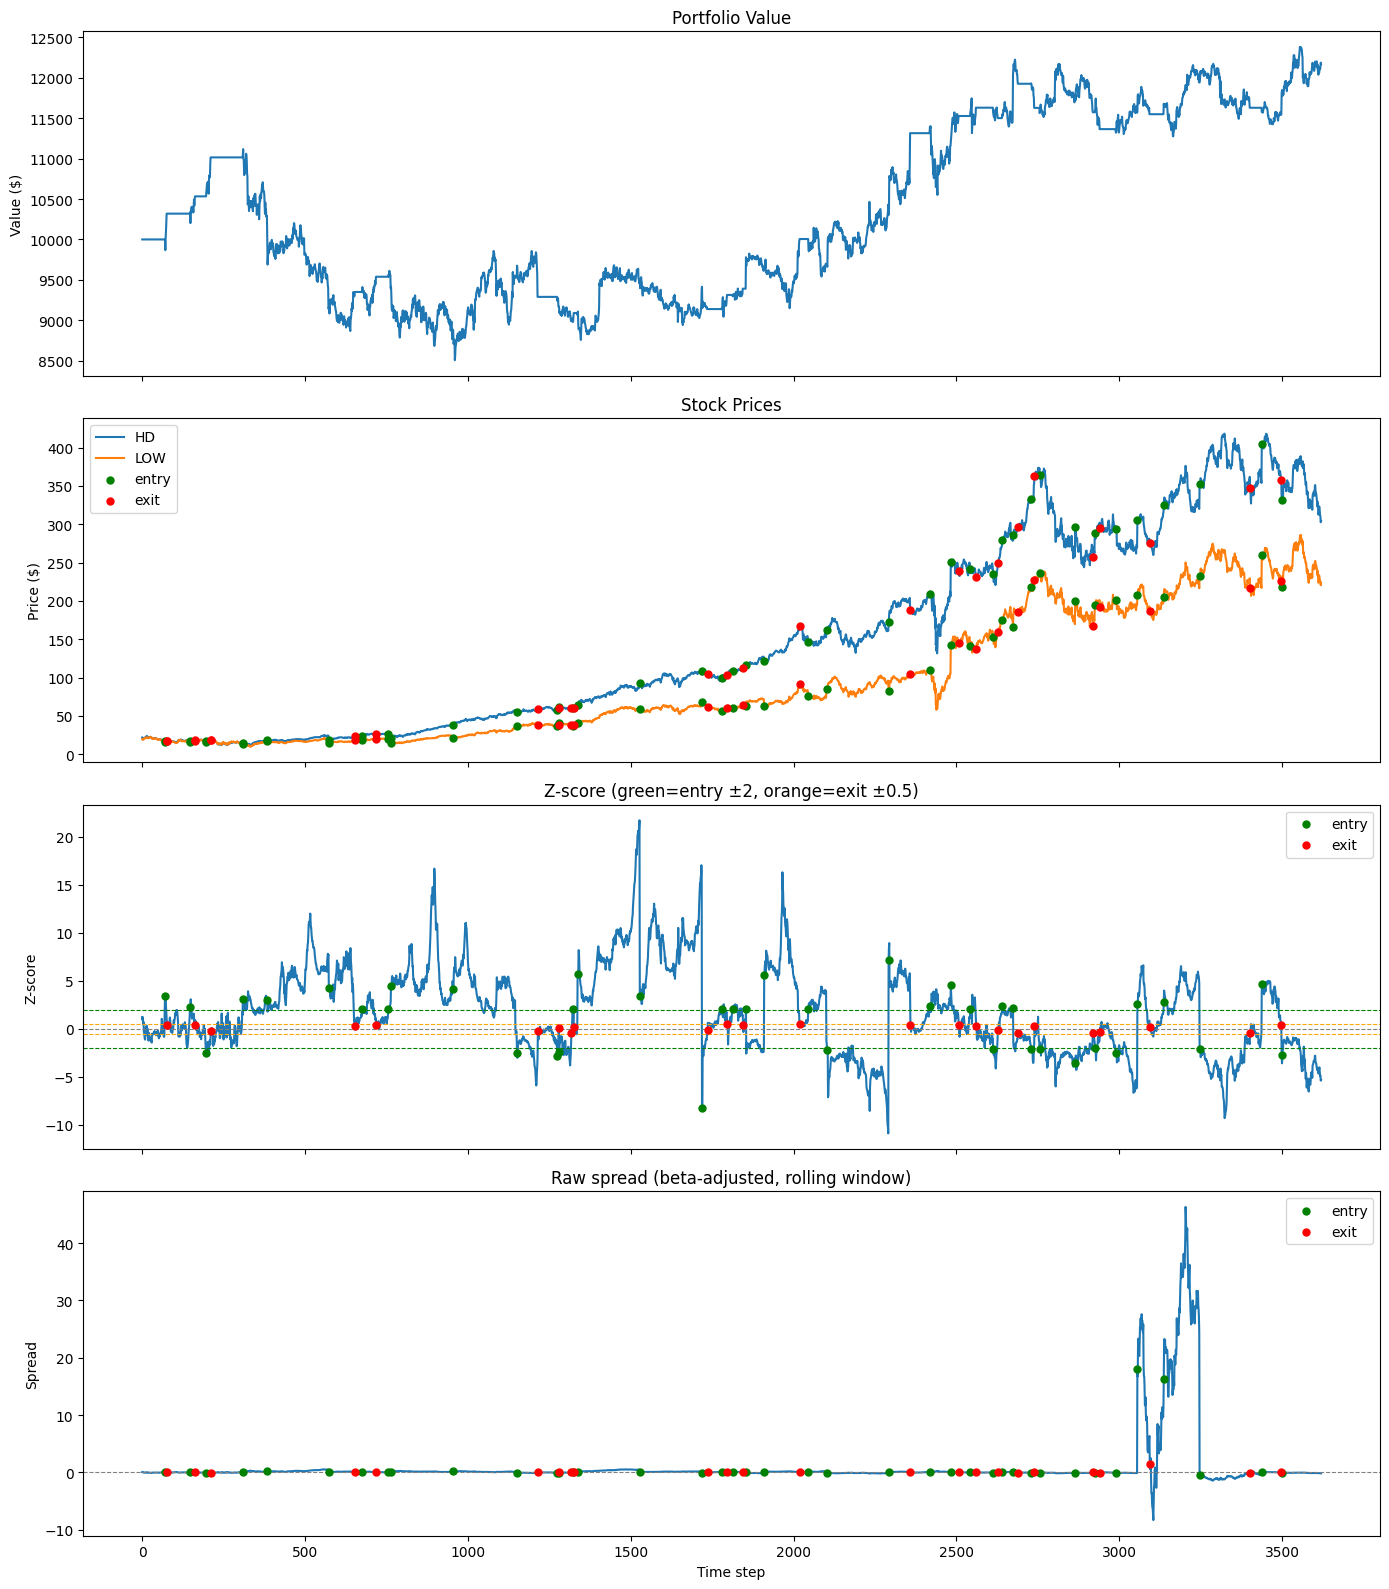


=== T/VZ ===
  year  1  β=1.388  end=$9926
  year  2  β=0.365  end=$9693
  year  3  β=2.128  end=$9956
  year  4  β=9.875  end=$9776
  year  5  β=0.713  end=$9832
  year  6  β=1.819  end=$8906
  year  7  β=0.351  end=$9016
  year  8  β=3.143  end=$9093
  year  9  β=0.330  end=$9325
  year 10  β=1.156  end=$9584
  year 11  β=0.391  end=$9262
  year 12  β=-0.648  end=$8864
  year 13  β=-0.030  end=$8464
  year 14  β=3.117  end=$8777
  year 15  β=-3.141  end=$9036
  year 16  β=-3.460  end=$9381
  year 17  β=0.134  end=$9869
  year 18  β=0.797  end=$11539
  year 19  β=4.548  end=$10467


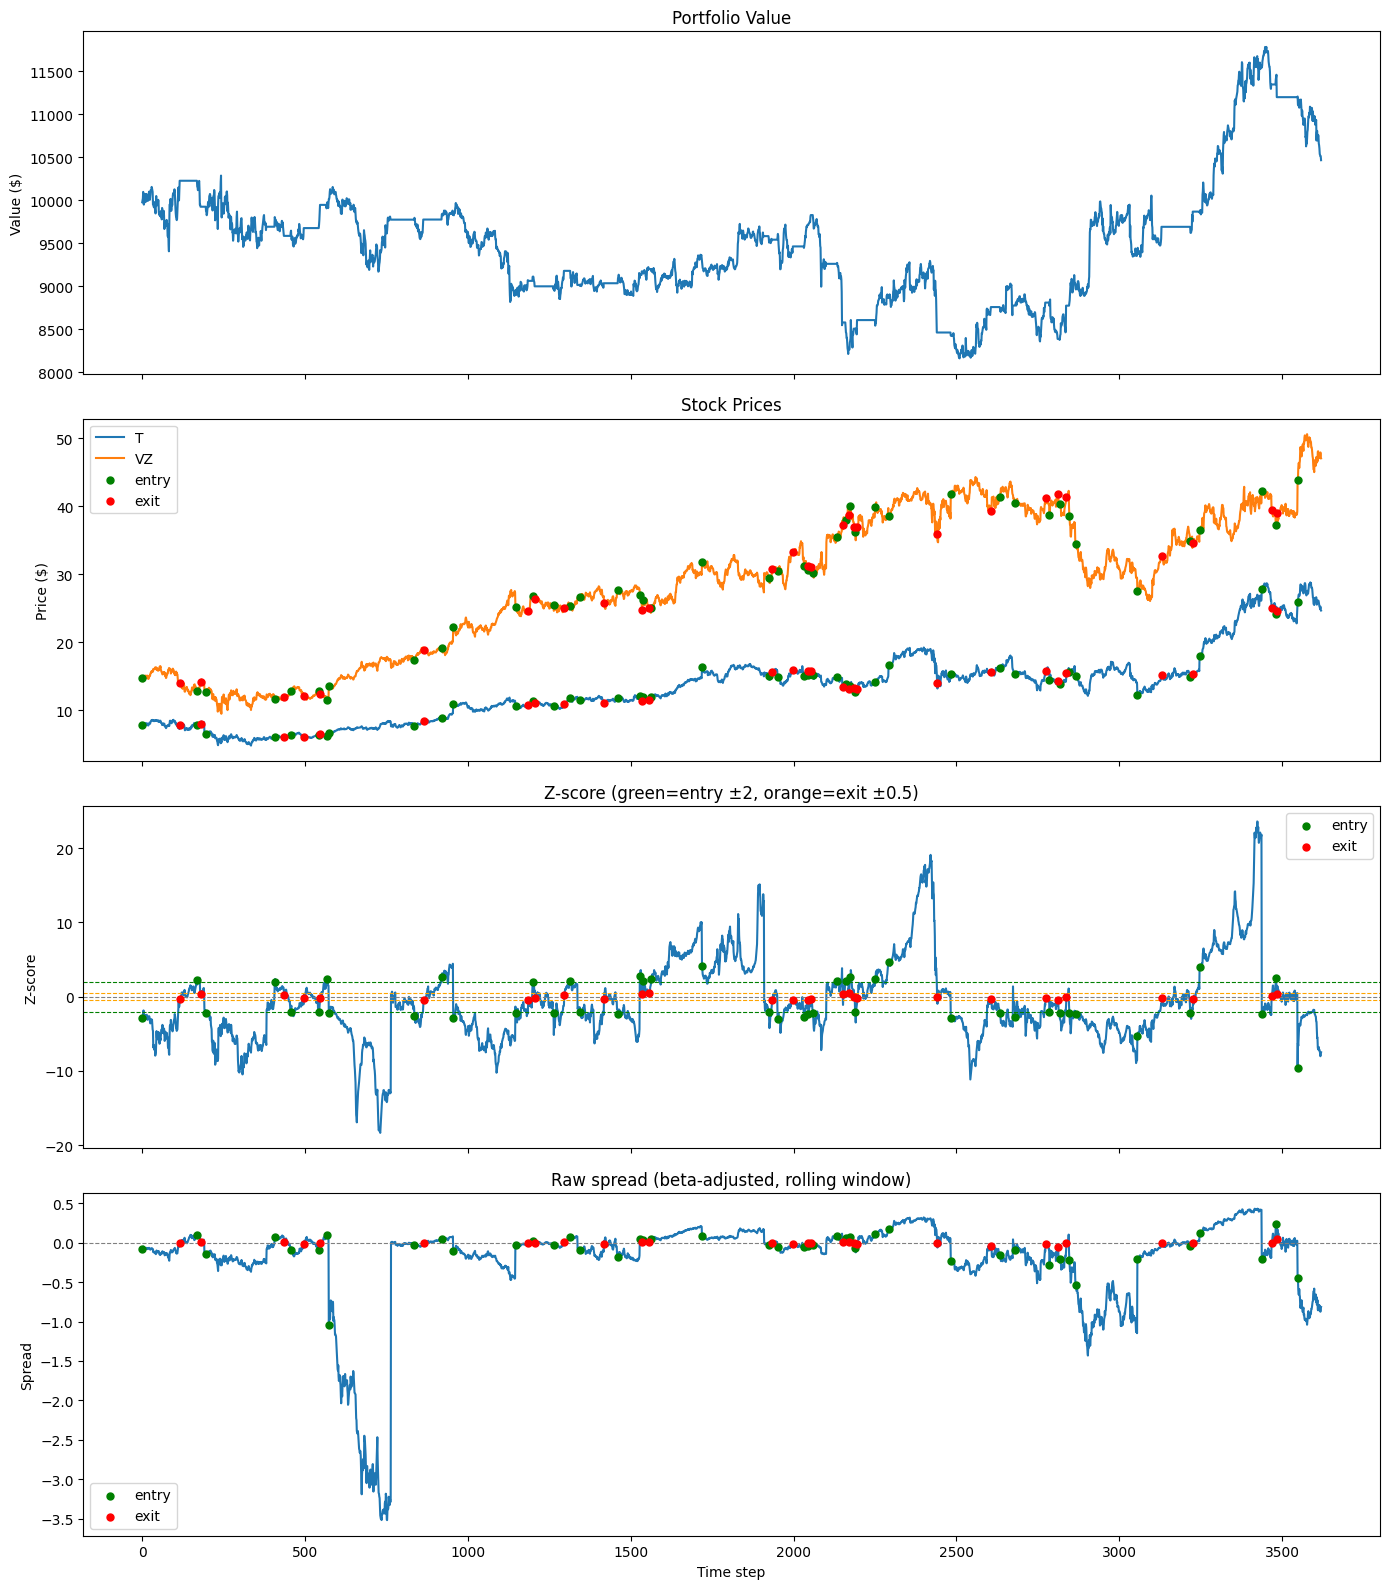

In [2]:
for t1, t2 in pairs:
    print(f"\n=== {t1}/{t2} ===")
    data = PairData(f"../../data/real_pair_{t1}_{t2}.csv")
    results = run_walkforward(data)
    plot_strategy(results)